In [2]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [3]:
df = pd.read_csv("data/dataset.csv")
df.head()

,text,clean_text,style,tone
0,Thank you for sharing your perspective with su...,thank you for share your perspective with such...,formal,sarcastic
1,You have a truly rare talent for making simple...,you have a truly rare talent for make simple s...,informal,sarcastic
2,You genuinely have the energy of someone who r...,you genuinely have the energy of someone who r...,informal,sarcastic
3,Hey! I am currently brainstorming some super f...,hey ! i be currently brainstorm some super fun...,informal,friendly
4,Your blatant insolence is unacceptable!!,your blatant insolence be unacceptable ! !,formal,aggressive


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   text        1000 non-null   str  
 1   clean_text  1000 non-null   str  
 2   style       1000 non-null   str  
 3   tone        1000 non-null   str  
dtypes: str(4)
memory usage: 31.4 KB


In [5]:
df.isnull().sum()

text          0
clean_text    0
style         0
tone          0
dtype: int64

style
formal      200
informal    200
literaly    200
academic    200
business    200
Name: count, dtype: int64


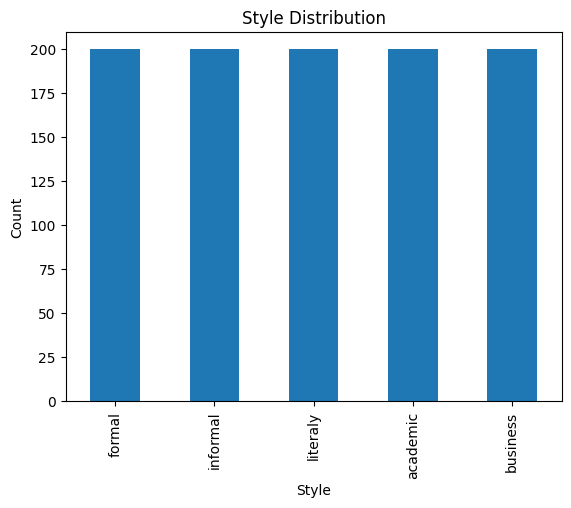

In [6]:
style_counts = df["style"].value_counts()

print(style_counts)

style_counts.plot(kind="bar")

plt.title("Style Distribution")
plt.xlabel("Style")
plt.ylabel("Count")

plt.show()

tone
sarcastic     200
friendly      200
aggressive    200
neutral       200
urgent        200
Name: count, dtype: int64


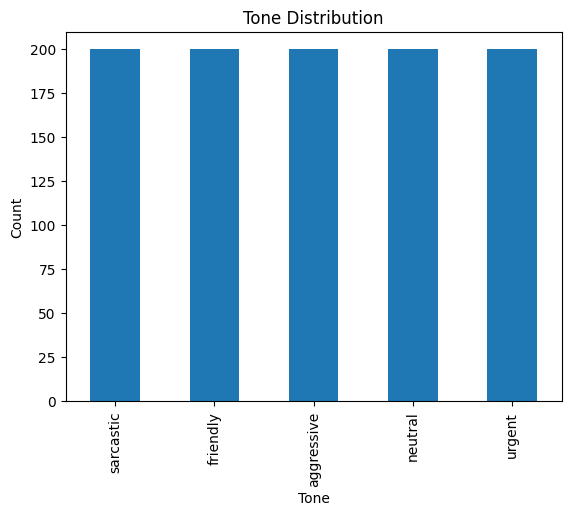

In [7]:
tone_counts = df["tone"].value_counts()

print(tone_counts)

tone_counts.plot(kind="bar")

plt.title("Tone Distribution")
plt.xlabel("Tone")
plt.ylabel("Count")

plt.show()

tone      aggressive  friendly  neutral  sarcastic  urgent
style                                                     
academic          40        40       40         40      40
business          40        40       40         40      40
formal            40        40       40         40      40
informal          40        40       40         40      40
literaly          40        40       40         40      40


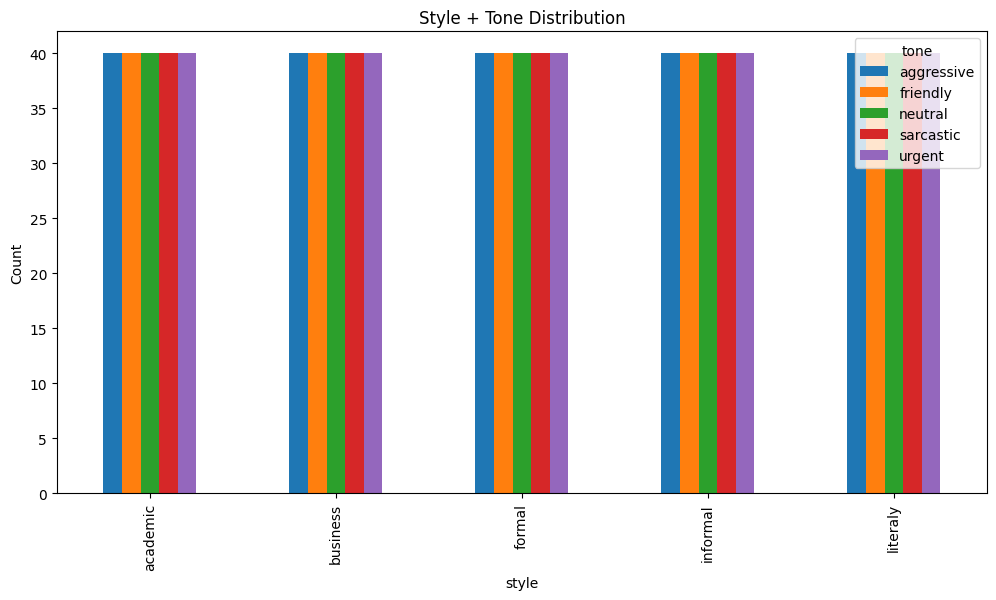

In [8]:
combo_counts = (
    df.groupby(["style", "tone"])
      .size()
      .unstack(fill_value=0)
)

print(combo_counts)

combo_counts.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Style + Tone Distribution")
plt.ylabel("Count")

plt.show()

In [9]:
df["clean_text"] = df["text"].astype(str)
df["text_length"] = df["clean_text"].apply(len)

df["text_length"].describe()

count    1000.000000
mean      398.786000
std       231.997899
min        10.000000
25%       200.000000
50%       399.000000
75%       596.000000
max       800.000000
Name: text_length, dtype: float64

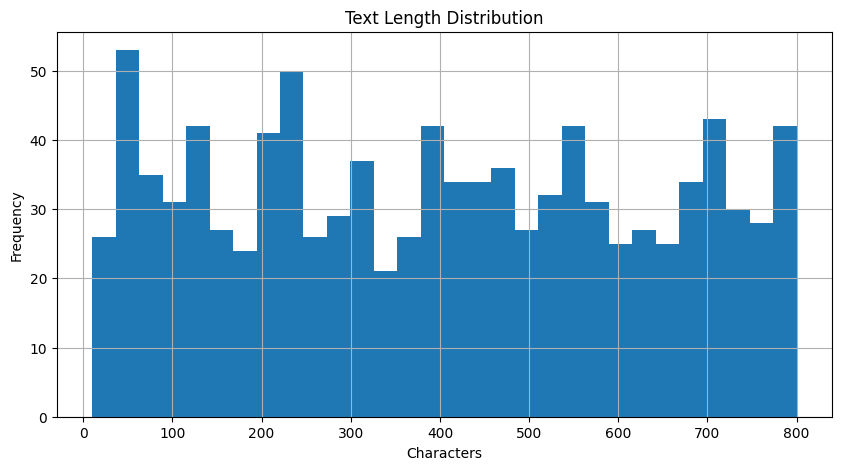

In [10]:
df["text_length"].hist(
    bins=30,
    figsize=(10, 5)
)

plt.title("Text Length Distribution")

plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

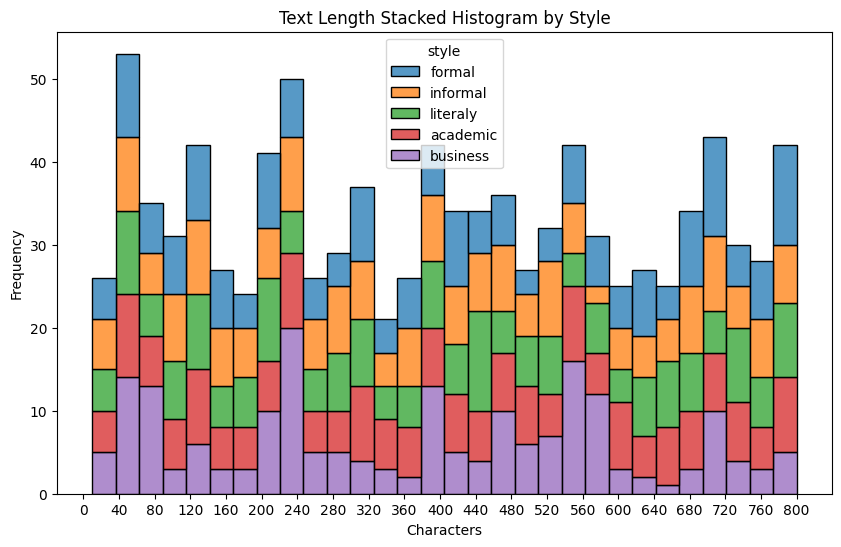

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="style",
    multiple="stack",
    bins=30
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(40))

plt.title("Text Length Stacked Histogram by Style")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

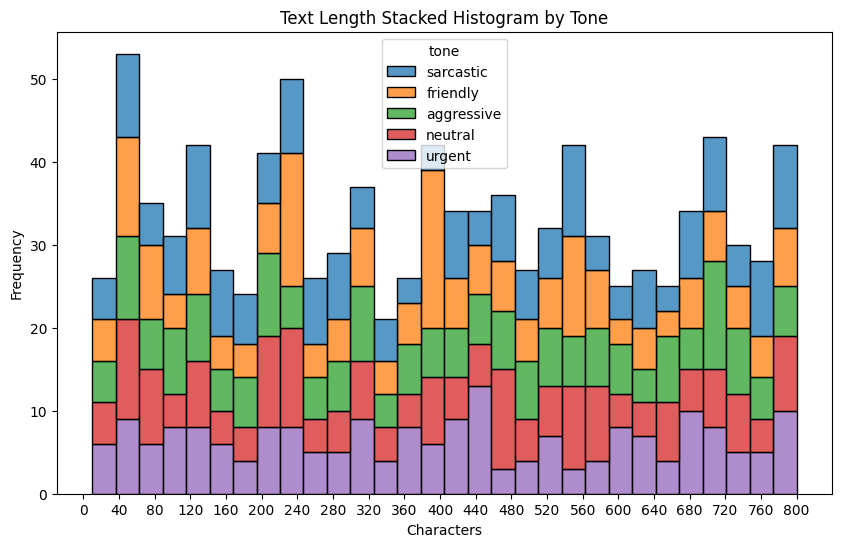

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="text_length",
    hue="tone",
    multiple="stack",
    bins=30
)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(40))
plt.title("Text Length Stacked Histogram by Tone")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [13]:
X = df["clean_text"]
y_style = df["style"]
y_tone = df["tone"]

X_train_style, X_test_style, y_train_style, y_test_style = train_test_split(
    X, y_style, test_size=0.2, random_state=42, stratify=y_style
)

X_train_tone, X_test_tone, y_train_tone, y_test_tone = train_test_split(
    X, y_tone, test_size=0.2, random_state=42, stratify=y_tone
)

pipeline = Pipeline(
    [("tfidf", TfidfVectorizer()), ("classifier", LinearSVC())]
)

param_grid = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "classifier__C": [0.1, 1, 10],
}


Tuning STYLE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best STYLE params:
{'classifier__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}

STYLE F1-score: 0.8923

STYLE Classification Report:

              precision    recall  f1-score   support

    academic       0.91      0.97      0.94        40
    business       0.80      0.80      0.80        40
      formal       0.91      0.72      0.81        40
    informal       0.89      1.00      0.94        40
    literaly       0.97      0.97      0.97        40

    accuracy                           0.90       200
   macro avg       0.90      0.89      0.89       200
weighted avg       0.90      0.90      0.89       200



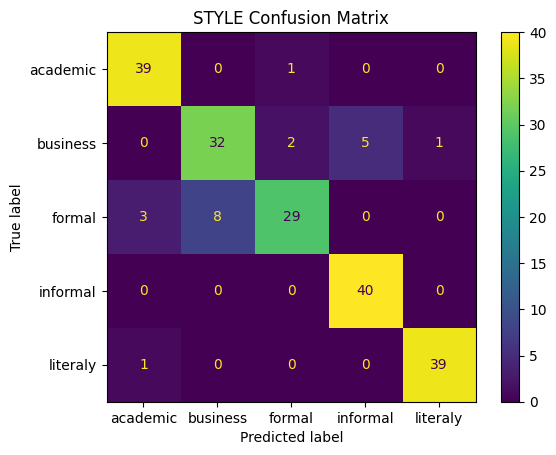


Saved style_model.pkl


In [14]:
print("\nTuning STYLE model...\n")

grid_style = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_style.fit(X_train_style, y_train_style)
best_style_model = grid_style.best_estimator_

print("Best STYLE params:")
print(grid_style.best_params_)

style_predictions = best_style_model.predict(X_test_style)
style_f1 = f1_score(y_test_style, style_predictions, average="weighted")
print(f"\nSTYLE F1-score: {style_f1:.4f}")

print("\nSTYLE Classification Report:\n")
print(classification_report(y_test_style, style_predictions))

style_cm = confusion_matrix(y_test_style, style_predictions)
disp_style = ConfusionMatrixDisplay(
    confusion_matrix=style_cm, display_labels=best_style_model.classes_
)
disp_style.plot()
plt.title("STYLE Confusion Matrix")
plt.show()

with open("style_model.pkl", "wb") as f:
    pickle.dump(best_style_model, f)
print("\nSaved style_model.pkl")


Tuning TONE model...

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best TONE params:
{'classifier__C': 10, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

TONE F1-score: 0.9594

TONE Classification Report:

              precision    recall  f1-score   support

  aggressive       1.00      1.00      1.00        40
    friendly       0.95      1.00      0.98        40
     neutral       0.90      0.95      0.93        40
   sarcastic       0.97      0.85      0.91        40
      urgent       0.98      1.00      0.99        40

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



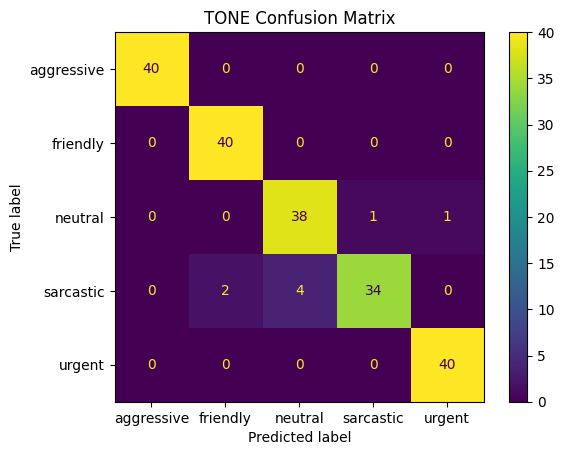


Saved tone_model.pkl


In [15]:
print("\nTuning TONE model...\n")

grid_tone = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    verbose=2,
    n_jobs=-1,
)

grid_tone.fit(X_train_tone, y_train_tone)
best_tone_model = grid_tone.best_estimator_

print("Best TONE params:")
print(grid_tone.best_params_)

tone_predictions = best_tone_model.predict(X_test_tone)
tone_f1 = f1_score(y_test_tone, tone_predictions, average="weighted")
print(f"\nTONE F1-score: {tone_f1:.4f}")

print("\nTONE Classification Report:\n")
print(classification_report(y_test_tone, tone_predictions))

tone_cm = confusion_matrix(y_test_tone, tone_predictions)
disp_tone = ConfusionMatrixDisplay(
    confusion_matrix=tone_cm, display_labels=best_tone_model.classes_
)
disp_tone.plot()
plt.title("TONE Confusion Matrix")
plt.show()

with open("tone_model.pkl", "wb") as f:
    pickle.dump(best_tone_model, f)
print("\nSaved tone_model.pkl")